ベイズ推論プログラミング for アイリスデータ・セット

In [1]:
%matplotlib inline

import numpy as np
import matplotlib.pyplot as plt
import japanize_matplotlib
import pandas as pd
from IPython.display import display
import seaborn as sns
np.set_printoptions(precision=3, floatmode='fixed')
plt.rcParams["font.size"] = 14
plt.rcParams["figure.figsize"] = (6,6)
plt.rcParams["axes.grid"] = True
pd.options.display.float_format = "{:.3f}".format
pd.set_option("display.max_columns", None)

from pprint import pprint

import pymc as pm
import arviz as az

print(f"Running on PyMC v{pm.__version__}")
print(f"Running on ArviZ v{az.__version__}")

/home/inoue/MyGithub/Book_BayesInference/.venv/lib/python3.12/site-packages/arviz/__init__.py:39: FutureWarning: 
ArviZ is undergoing a major refactor to improve flexibility and extensibility while maintaining a user-friendly interface.
Some upcoming changes may be backward incompatible.
For details and migration guidance, visit: https://python.arviz.org/en/latest/user_guide/migration_guide.html
  warn(


Running on PyMC v5.27.0
Running on ArviZ v0.23.0


# No.1 データ分布のベイズ推定

In [2]:
# アイリス・データ・セットの読み込み
df = sns.load_dataset('iris')

display(df.head())

df['species'].value_counts()

,sepal_length,sepal_width,petal_length,petal_width,species
0,5.100,3.500,1.400,0.200,setosa
1,4.900,3.000,1.400,0.200,setosa
2,4.700,3.200,1.300,0.200,setosa
3,4.600,3.100,1.500,0.200,setosa
4,5.000,3.600,1.400,0.200,setosa


species
setosa        50
versicolor    50
virginica     50
Name: count, dtype: int64

([<matplotlib.axis.XTick at 0x7f3f3b80f470>,
 [Text(4.0, 0, '4.0'),
  Text(4.2, 0, '4.2'),
  Text(4.4, 0, '4.4'),
  Text(4.6000000000000005, 0, '4.6'),
  Text(4.800000000000001, 0, '4.8'),
  Text(5.000000000000001, 0, '5.0'),
  Text(5.200000000000001, 0, '5.2'),
  Text(5.400000000000001, 0, '5.4'),
  Text(5.600000000000001, 0, '5.6'),
  Text(5.800000000000002, 0, '5.8'),
  Text(6.000000000000002, 0, '6.0')])

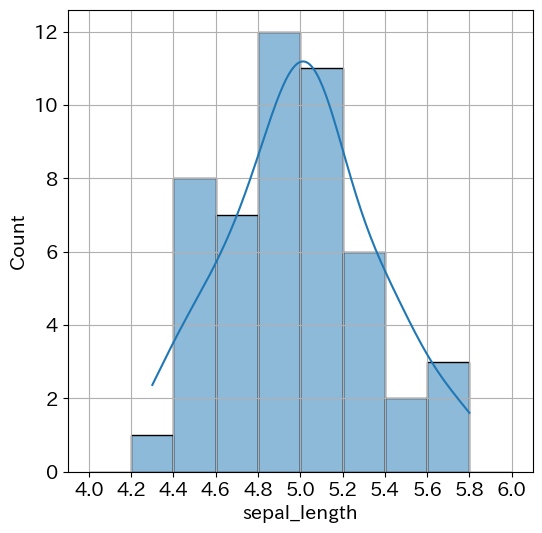

In [3]:
# setosaの行のみ取得
df1 = df.query('species == "setosa"')

bins = np.arange(4.0, 6.2, 0.2)

sns.histplot(df1, x='sepal_length', bins=bins, kde=True)
plt.xticks(bins)

In [4]:
# sepal_length列の抽出
s1 = df1['sepal_length']
X = s1.values
print(s1.describe()) # 統計情報の表示
print(X)

count   50.000
mean     5.006
std      0.352
min      4.300
25%      4.800
50%      5.000
75%      5.200
max      5.800
Name: sepal_length, dtype: float64
[5.100 4.900 4.700 4.600 5.000 5.400 4.600 5.000 4.400 4.900 5.400 4.800
 4.800 4.300 5.800 5.700 5.400 5.100 5.700 5.100 5.400 5.100 4.600 5.100
 4.800 5.000 5.000 5.200 5.200 4.700 4.800 5.400 5.200 5.500 4.900 5.000
 5.500 4.900 4.400 5.100 5.000 4.500 4.400 5.000 5.100 4.800 5.100 4.600
 5.300 5.000]


In [5]:
# 正規分布の確率モデル定義
model1 = pm.Model()

with model1:
    mu = pm.Normal('mu', mu=0.0, sigma=10.0)
    sigma = pm.HalfNormal('sigma', sigma=10.0)
    X_obs = pm.Normal('X_obs', mu=mu, sigma=sigma, observed=X)

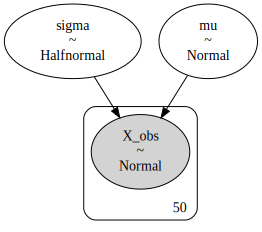

In [6]:
g = pm.model_to_graphviz(model1)
display(g)

In [7]:
# サンプリング
with model1:
    idata1 = pm.sample(random_seed=42)

Initializing NUTS using jitter+adapt_diag...
Multiprocess sampling (4 chains in 4 jobs)
NUTS: [mu, sigma]


Output()

Sampling 4 chains for 1_000 tune and 1_000 draw iterations (4_000 + 4_000 draws total) took 1 seconds.


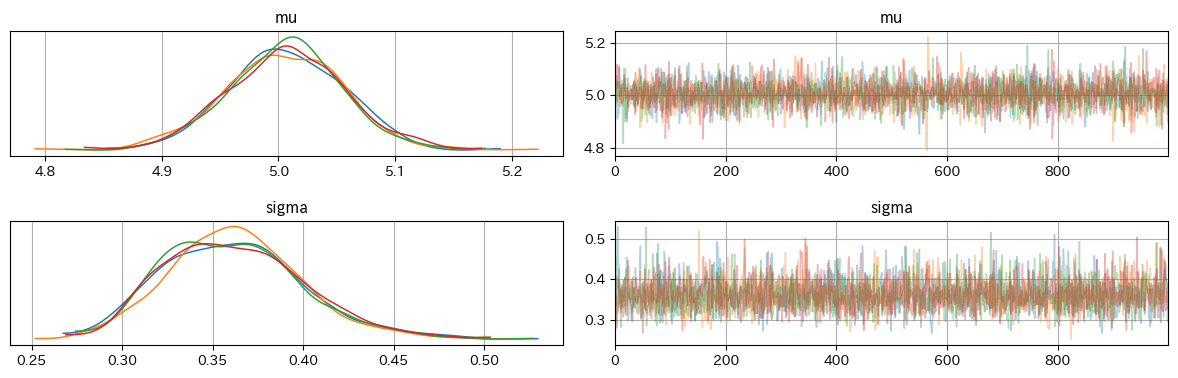

In [8]:
# 分析結果
az.plot_trace(idata1, compact=False)
plt.tight_layout()

In [9]:
idata1

Inference data with groups:
	> posterior
	> sample_stats
	> observed_data

array([<Axes: title={'center': 'mu'}>, <Axes: title={'center': 'sigma'}>],
      dtype=object)

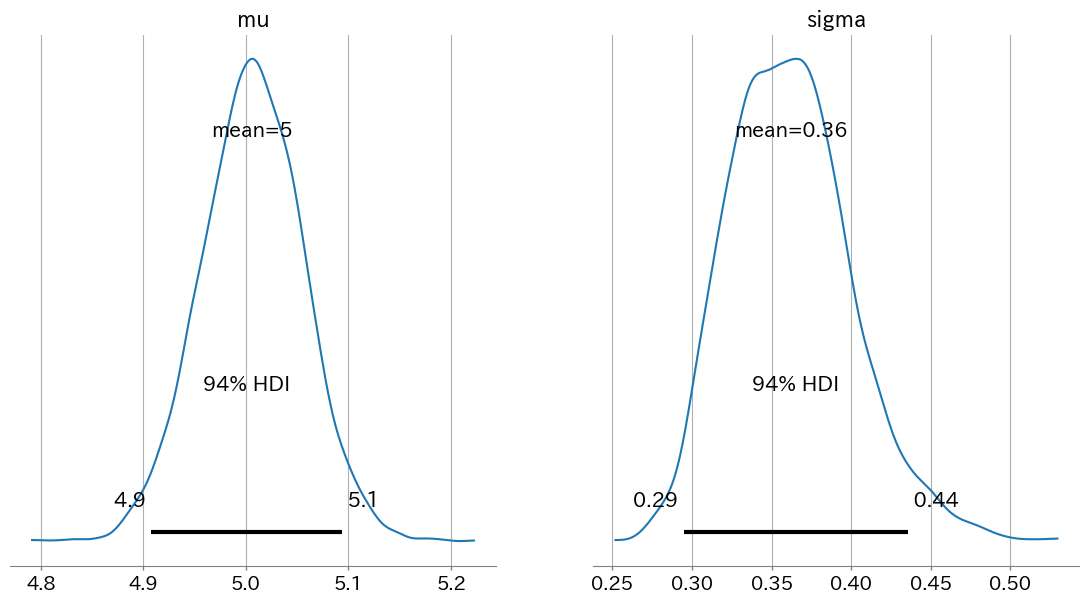

In [10]:
az.plot_posterior(idata1)

In [11]:
summary1 = az.summary(idata1)
display(summary1)

,mean,sd,hdi_3%,hdi_97%,mcse_mean,mcse_sd,ess_bulk,ess_tail,r_hat
mu,5.006,0.050,4.908,5.094,0.001,0.001,3718.000,2711.000,1.000
sigma,0.362,0.039,0.295,0.436,0.001,0.001,3437.000,2488.000,1.000


In [12]:
mu_mean1 = summary1.loc['mu','mean']
sigma_mean1 = summary1.loc['sigma', 'mean']
print(f"mu={mu_mean1}, sigma={sigma_mean1}")

mu=5.006, sigma=0.362


ヒストグラムと正規分布関数の重ね書き

In [13]:
def norm(x, mu, sigma):
    y = (x-mu)/sigma
    a = np.exp(-(y**2)/2)
    b = np.sqrt(2*np.pi)*sigma
    return a/b

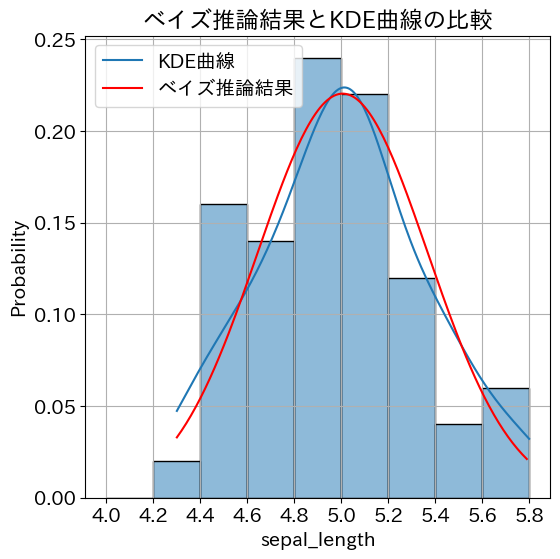

In [14]:
# ベイズ推論結果に基づく計算
x_min = X.min()
x_max = X.max()
x_list = np.arange(x_min, x_max, 0.01)
y_list = norm(x_list, mu_mean1, sigma_mean1)

# ヒストグラムにベイズ推論結果に基づく正規分布とKDE曲線を重ねる
delta = 0.2
bins = np.arange(4.0, 6.0, delta)
fig, ax = plt.subplots()
sns.histplot(df1, ax=ax, x='sepal_length', bins=bins, kde=True, stat='probability')
ax.get_lines()[0].set_label('KDE曲線')
ax.set_xticks(bins)
ax.plot(x_list, y_list*delta, c='r', label='ベイズ推論結果')
ax.set_title("ベイズ推論結果とKDE曲線の比較")
plt.legend()

少ないサンプル数でのベイズ推論

In [15]:
# irisの先頭5件のみデータをサンプルとして使う
X_less = X[:5]

print(X_less)

pd.Series(X_less).describe()

[5.100 4.900 4.700 4.600 5.000]


count   5.000
mean    4.860
std     0.207
min     4.600
25%     4.700
50%     4.900
75%     5.000
max     5.100
dtype: float64

In [16]:
# モデリングとサンプリング
model2 = pm.Model()

with model2:
    mu = pm.Normal('mu', mu=0.0, sigma=10.0)
    sigma = pm.HalfNormal('sigma', sigma=10.0)
    X_obs = pm.Normal('X_obs', mu=mu, sigma=sigma, observed=X_less)

    # サンプリング
    idata2 = pm.sample(random_seed=42)

Initializing NUTS using jitter+adapt_diag...
Multiprocess sampling (4 chains in 4 jobs)
NUTS: [mu, sigma]


Output()

Sampling 4 chains for 1_000 tune and 1_000 draw iterations (4_000 + 4_000 draws total) took 1 seconds.
There was 1 divergence after tuning. Increase `target_accept` or reparameterize.
The rhat statistic is larger than 1.01 for some parameters. This indicates problems during sampling. See https://arxiv.org/abs/1903.08008 for details


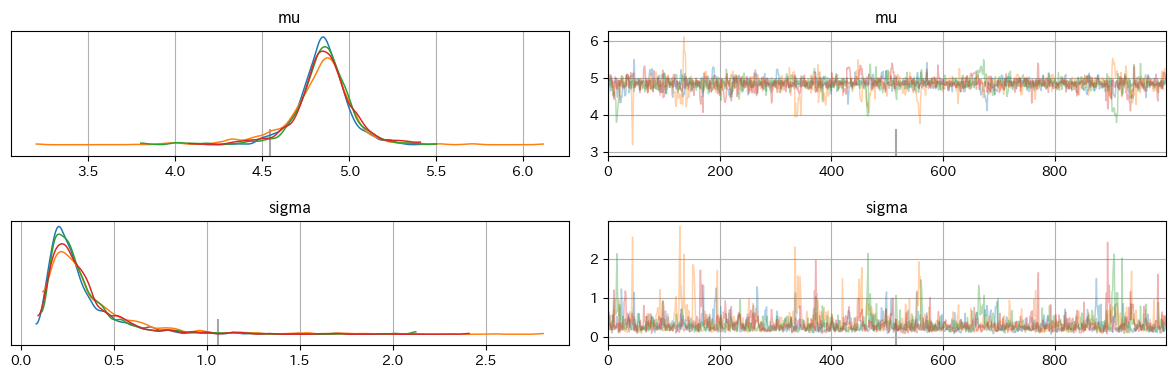

In [17]:
# 分析結果
az.plot_trace(idata2, compact=False)
plt.tight_layout()

In [18]:
summary2 = az.summary(idata2)
display(summary2)

,mean,sd,hdi_3%,hdi_97%,mcse_mean,mcse_sd,ess_bulk,ess_tail,r_hat
mu,4.843,0.179,4.495,5.164,0.006,0.010,1203.000,708.000,1.010
sigma,0.343,0.237,0.109,0.713,0.009,0.015,911.000,1048.000,1.010


array([<Axes: title={'center': 'mu'}>, <Axes: title={'center': 'sigma'}>],
      dtype=object)

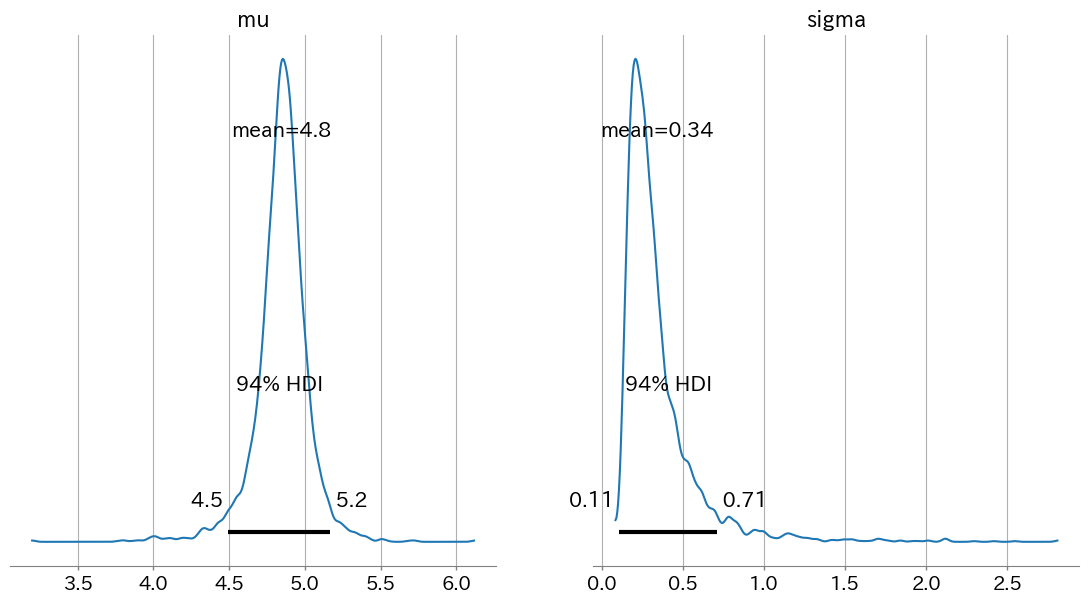

In [19]:
az.plot_posterior(idata2)

tauによる確率モデルの定義

In [20]:
model3 = pm.Model()

with model3:
    mu = pm.Normal('mu', mu=0.0, sigma=10.0)
    tau = pm.HalfNormal('tau', sigma=10.0)
    X_obs = pm.Normal('X_obs', mu=mu, tau=tau, observed=X)
    sigma = pm.Deterministic('sigma', 1/pm.math.sqrt(tau))

    idata3 = pm.sample(random_seed=42)

Initializing NUTS using jitter+adapt_diag...
Multiprocess sampling (4 chains in 4 jobs)
NUTS: [mu, tau]


Output()

Sampling 4 chains for 1_000 tune and 1_000 draw iterations (4_000 + 4_000 draws total) took 1 seconds.


In [21]:
summary3 = az.summary(idata3)
display(summary3)

,mean,sd,hdi_3%,hdi_97%,mcse_mean,mcse_sd,ess_bulk,ess_tail,r_hat
mu,5.005,0.050,4.917,5.108,0.001,0.001,3886.000,2784.000,1.000
tau,8.177,1.616,5.211,11.252,0.025,0.026,4052.000,2700.000,1.000
sigma,0.355,0.036,0.290,0.421,0.001,0.001,4052.000,2700.000,1.000


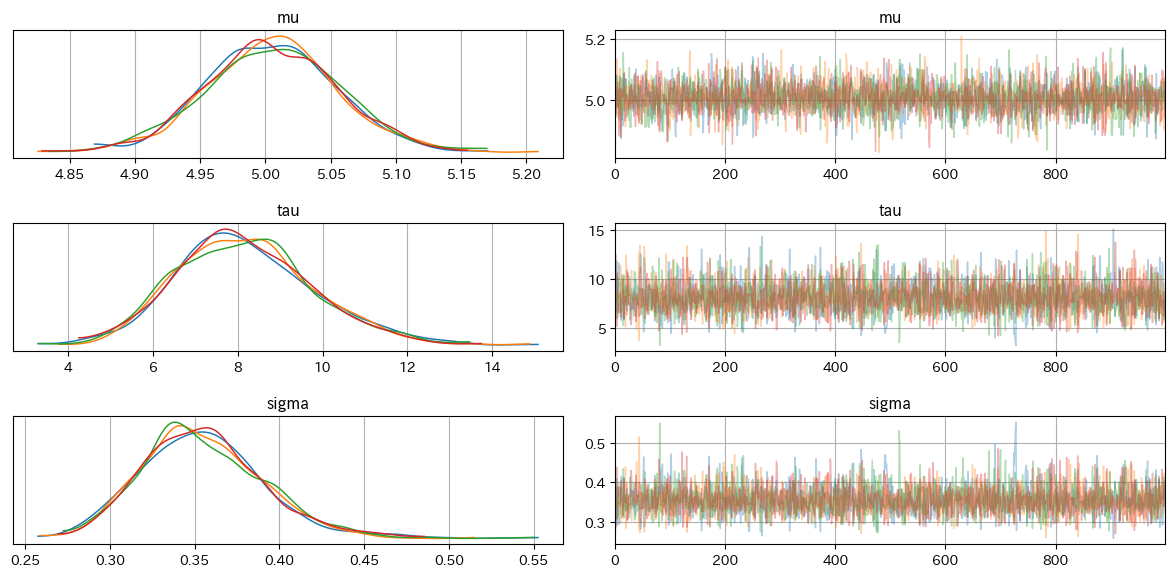

In [22]:
# 分析結果
az.plot_trace(idata3, compact=False)
plt.tight_layout()

array([<Axes: title={'center': 'mu'}>, <Axes: title={'center': 'tau'}>,
       <Axes: title={'center': 'sigma'}>], dtype=object)

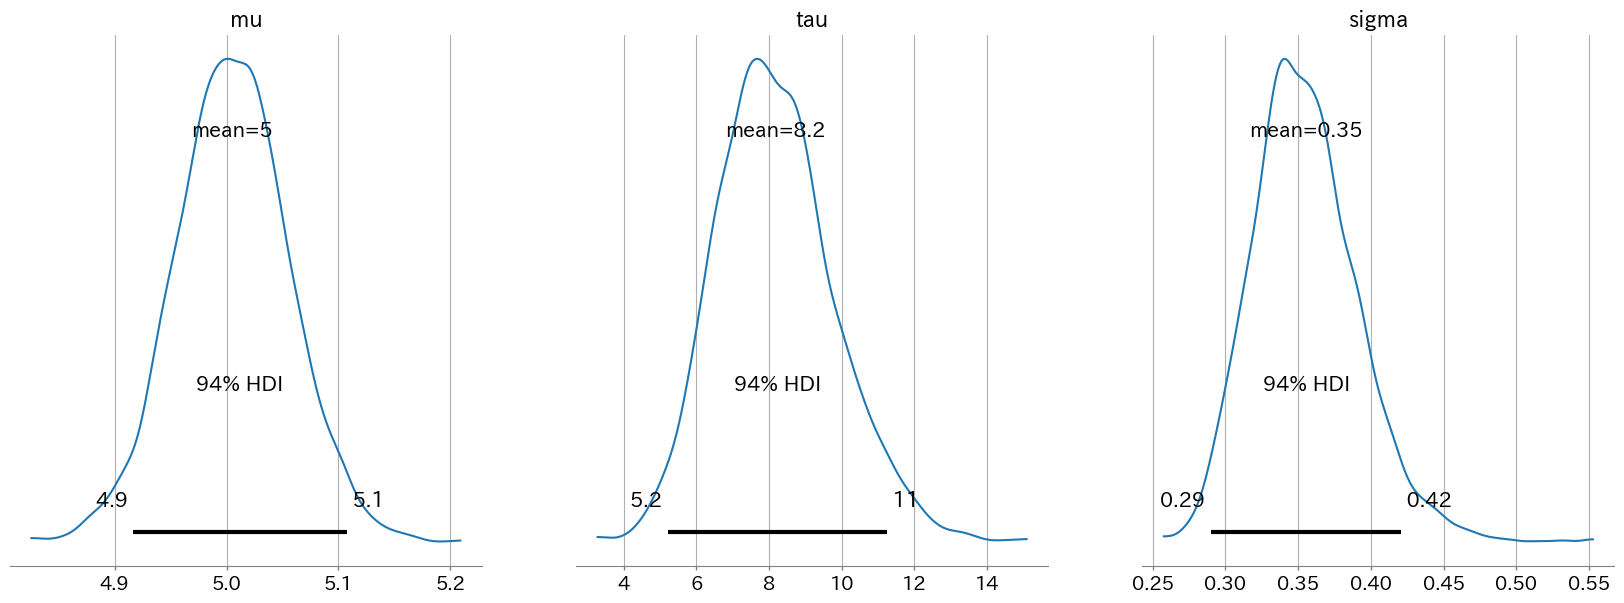

In [23]:
az.plot_posterior(idata3)

# No.2 線形回帰のベイズ推論

+ versicolor
1. sepal_length
2. sepal_width

2つの項目の観測値の関係性を示すパラメータをベイズ推論で求める

In [24]:
# データ準備
df = sns.load_dataset('iris')
display(df.head())
df['species'].value_counts()

,sepal_length,sepal_width,petal_length,petal_width,species
0,5.100,3.500,1.400,0.200,setosa
1,4.900,3.000,1.400,0.200,setosa
2,4.700,3.200,1.300,0.200,setosa
3,4.600,3.100,1.500,0.200,setosa
4,5.000,3.600,1.400,0.200,setosa


species
setosa        50
versicolor    50
virginica     50
Name: count, dtype: int64

In [25]:
# データ抽出
df1 = df.query('species == "versicolor"')
X = df1['sepal_length']
Y = df1['sepal_width']

Text(0, 0.5, 'sepal_width')

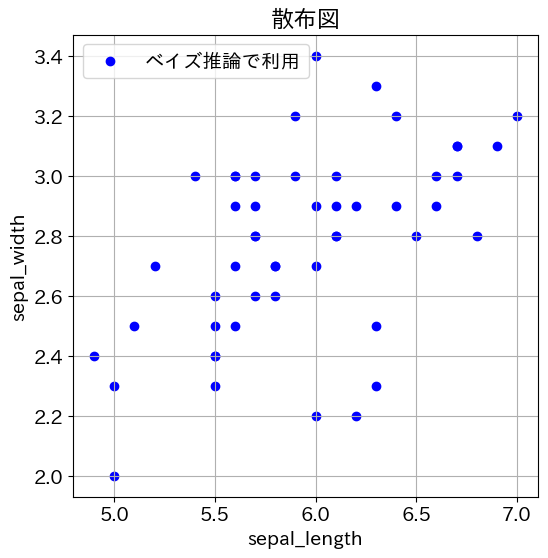

In [26]:
# 散布図
plt.title("散布図")
plt.scatter(X,Y,label="ベイズ推論で利用",c='b',marker='o')
plt.legend()
plt.xlabel('sepal_length')
plt.ylabel('sepal_width')

In [27]:
# Y_n = αX_n + β + ε_n

# 線形回帰の確率モデル
model1 = pm.Model()
with model1:
    # 確率変数alpha, betaの定義
    alpha = pm.Normal('alpha', mu=0.0, sigma=10.0)
    beta = pm.Normal('beta', mu=0.0, sigma=10.0)

    # 平均値muの計算
    mu = alpha * X + beta

    # 誤差を示す確率変数epsilonの定義
    epsilon = pm.HalfNormal('epsilon', sigma=1.0)

    # 観測値を持つ確率変数はY_obsとして定義
    Y_obs = pm.Normal('Y_obs', mu=mu, sigma=epsilon, observed=Y)

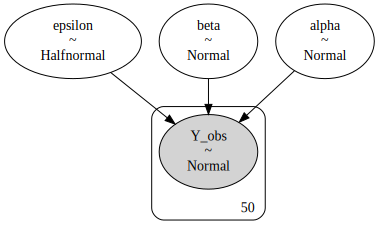

In [28]:
# 確率モデル構造の可視化
g = pm.model_to_graphviz(model1)
display(g)

In [29]:
# Xを観測値として認識させるための改善モデル
model2 = pm.Model()
with model2:
    # X, Yの観測値をConstantDataとして定義
    X_data = pm.Data('X_data', X)
    Y_data = pm.Data('Y_data', Y)

    alpha = pm.Normal('alpha', mu=0.0, sigma=10.0)
    beta = pm.Normal('beta', mu=0.0, sigma=10.0)

    # 平均mu
    mu = pm.Deterministic('mu', alpha * X_data + beta)

    epsilon = pm.HalfNormal('epsilon', sigma=1.0)

    obs = pm.Normal('obs', mu=mu, sigma=epsilon, observed=Y_data)

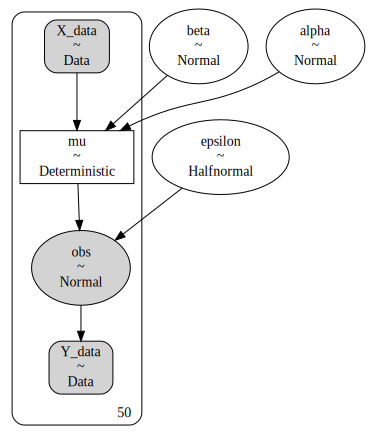

In [30]:
g = pm.model_to_graphviz(model2)
display(g)

In [31]:
with model2:
    idata2 = pm.sample(random_seed=42)

Initializing NUTS using jitter+adapt_diag...
Multiprocess sampling (4 chains in 4 jobs)
NUTS: [alpha, beta, epsilon]


Output()

Sampling 4 chains for 1_000 tune and 1_000 draw iterations (4_000 + 4_000 draws total) took 4 seconds.


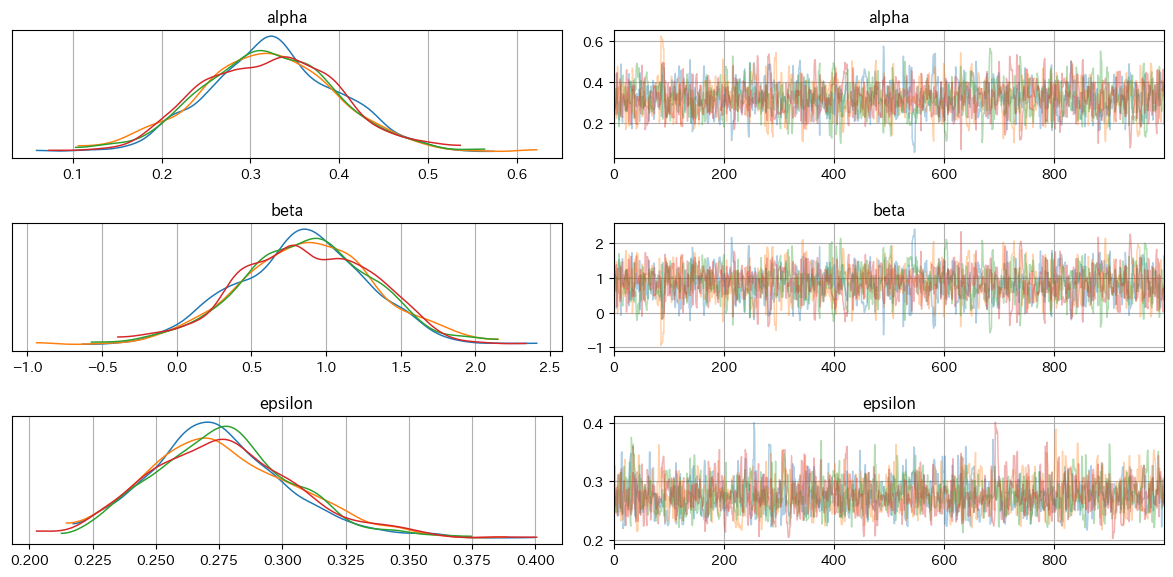

In [32]:
az.plot_trace(idata2, compact=False, var_names=['alpha','beta','epsilon'])
plt.tight_layout()

In [33]:
summary2 = az.summary(idata2)
display(summary2)

,mean,sd,hdi_3%,hdi_97%,mcse_mean,mcse_sd,ess_bulk,ess_tail,r_hat
alpha,0.322,0.077,0.174,0.463,0.002,0.002,1483.000,1586.000,1.000
beta,0.861,0.460,0.005,1.727,0.012,0.010,1484.000,1588.000,1.000
epsilon,0.277,0.029,0.224,0.328,0.001,0.001,1692.000,1321.000,1.000
mu[0],3.113,0.091,2.948,3.283,0.002,0.002,1739.000,2021.000,1.000
mu[1],2.920,0.054,2.823,3.025,0.001,0.001,2429.000,2685.000,1.000
mu[2],3.081,0.084,2.932,3.242,0.002,0.002,1786.000,2013.000,1.000
mu[3],2.630,0.052,2.524,2.722,0.001,0.001,2319.000,2272.000,1.000
mu[4],2.952,0.059,2.839,3.060,0.001,0.001,2212.000,2447.000,1.000
mu[5],2.695,0.044,2.613,2.780,0.001,0.001,3111.000,2701.000,1.000
mu[6],2.888,0.049,2.794,2.978,0.001,0.001,2761.000,2599.000,1.000


array([<Axes: title={'center': 'alpha'}>,
       <Axes: title={'center': 'beta'}>,
       <Axes: title={'center': 'epsilon'}>], dtype=object)

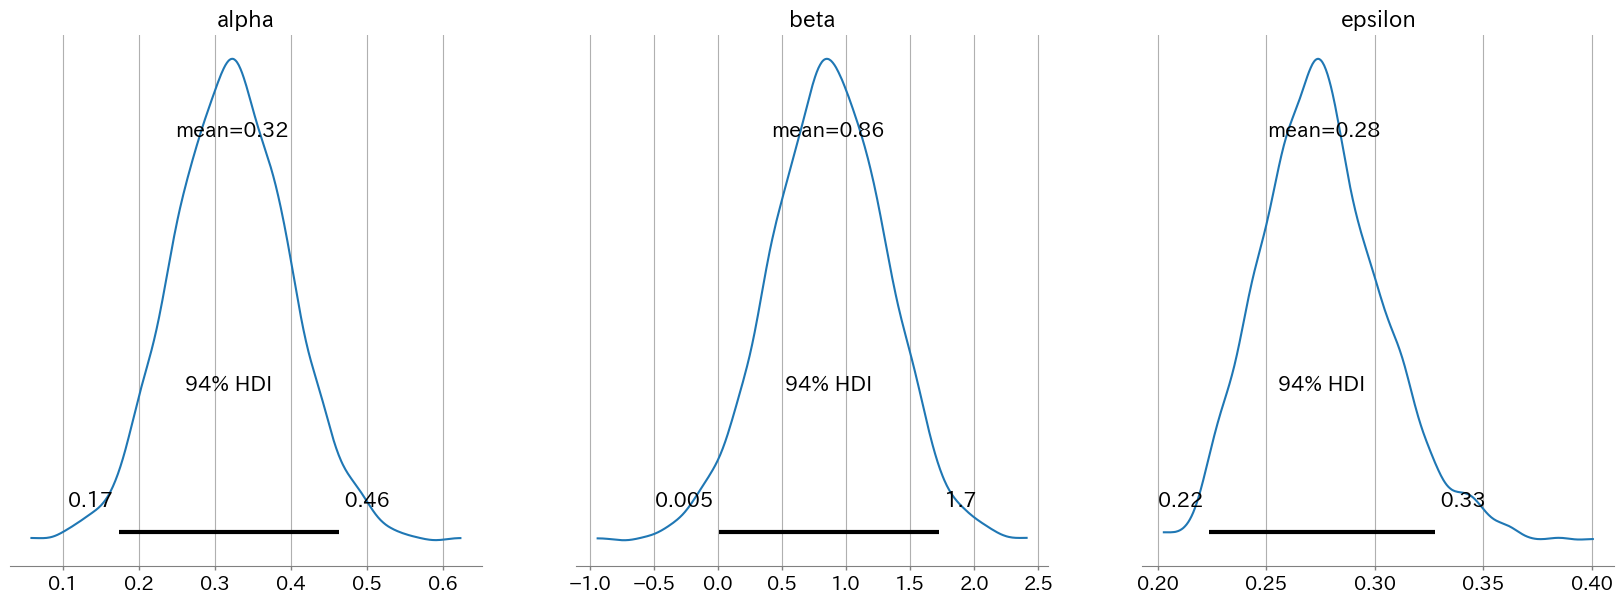

In [34]:
az.plot_posterior(idata2, var_names=['alpha','beta','epsilon'])

散布図と回帰直線の重ね書き

In [35]:
# xの2点をNumpy配列にする
x_values = np.array([X.min()-0.1, X.max()+0.1])
print(x_values, x_values.shape)

# サンプリング結果からalphaとbetaを取り出して形状を加工
alphas2 = idata2['posterior']['alpha'].values.reshape(-1, 1)
betas2 = idata2['posterior']['beta'].values.reshape(-1, 1)

print(alphas2.shape, betas2.shape)

[4.800 7.100] (2,)
(4000, 1) (4000, 1)


In [36]:
alphas2[:5,:]

array([[0.388],
       [0.354],
       [0.275],
       [0.287],
       [0.289]])

In [37]:
y_preds = x_values * alphas2 + betas2
print(y_preds.shape)

(4000, 2)


Text(0, 0.5, 'sepal_width')

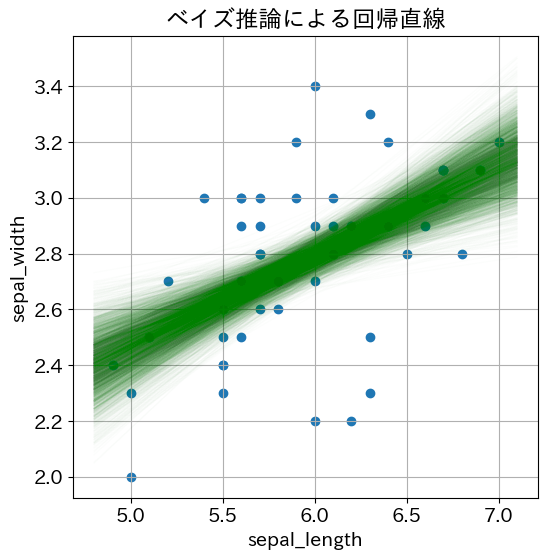

In [38]:
for y_pred in y_preds:
    plt.plot(x_values, y_pred, lw=1, alpha=0.01, c='g')
plt.scatter(X, Y)
plt.title('ベイズ推論による回帰直線')
plt.xlabel("sepal_length")
plt.ylabel('sepal_width')

少ない観測値でのベイズ推論

In [39]:
# 観測値数の絞り込み
import random
random.seed(42)
indice = range(len(X))
sample_indice = random.sample(indice, 3)
print('インデックス値', sample_indice)

# データ数を3個にする
X_less = X.iloc[sample_indice]
Y_less = Y.iloc[sample_indice]
print("xの値 ", X_less.values)
print("yの値 ", Y_less.values)

インデックス値 [40, 7, 1]
xの値  [5.500 4.900 6.400]
yの値  [2.600 2.400 3.200]


Text(0, 0.5, 'sepal_width')

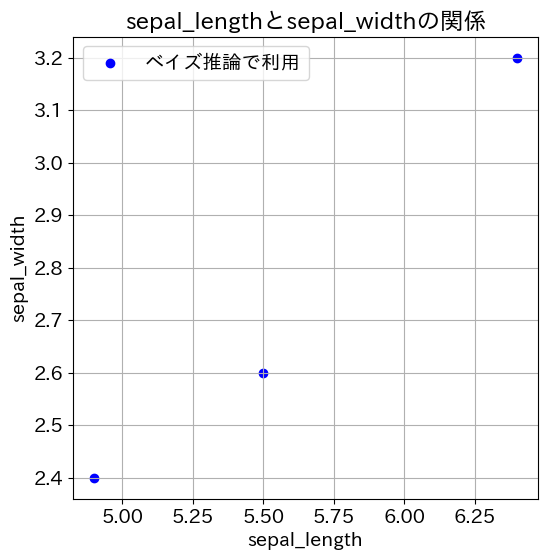

In [40]:
plt.title('sepal_lengthとsepal_widthの関係')
plt.scatter(X_less, Y_less, label="ベイズ推論で利用", c='b', marker='o')
plt.legend()
plt.xlabel('sepal_length')
plt.ylabel('sepal_width')

In [41]:
model3 = pm.Model()

with model3:
    X_data = pm.Data('X_data', X_less)
    Y_data = pm.Data('Y_data', Y_less)

    alpha = pm.Normal('alpha', mu=0, sigma=10.0)
    beta = pm.Normal('beta', mu=0.0, sigma=10.0)

    # 平均muの計算
    mu = pm.Deterministic('mu', alpha * X_data + beta)

    epsilon = pm.HalfNormal('epsilon', sigma=1.0)

    obs = pm.Normal('obs', mu=mu, sigma=epsilon, observed=Y_data)

    idata3 = pm.sample(random_seed=42, target_accept=0.995)

Initializing NUTS using jitter+adapt_diag...
Multiprocess sampling (4 chains in 4 jobs)
NUTS: [alpha, beta, epsilon]


Output()

Sampling 4 chains for 1_000 tune and 1_000 draw iterations (4_000 + 4_000 draws total) took 14 seconds.
The rhat statistic is larger than 1.01 for some parameters. This indicates problems during sampling. See https://arxiv.org/abs/1903.08008 for details
The effective sample size per chain is smaller than 100 for some parameters.  A higher number is needed for reliable rhat and ess computation. See https://arxiv.org/abs/1903.08008 for details


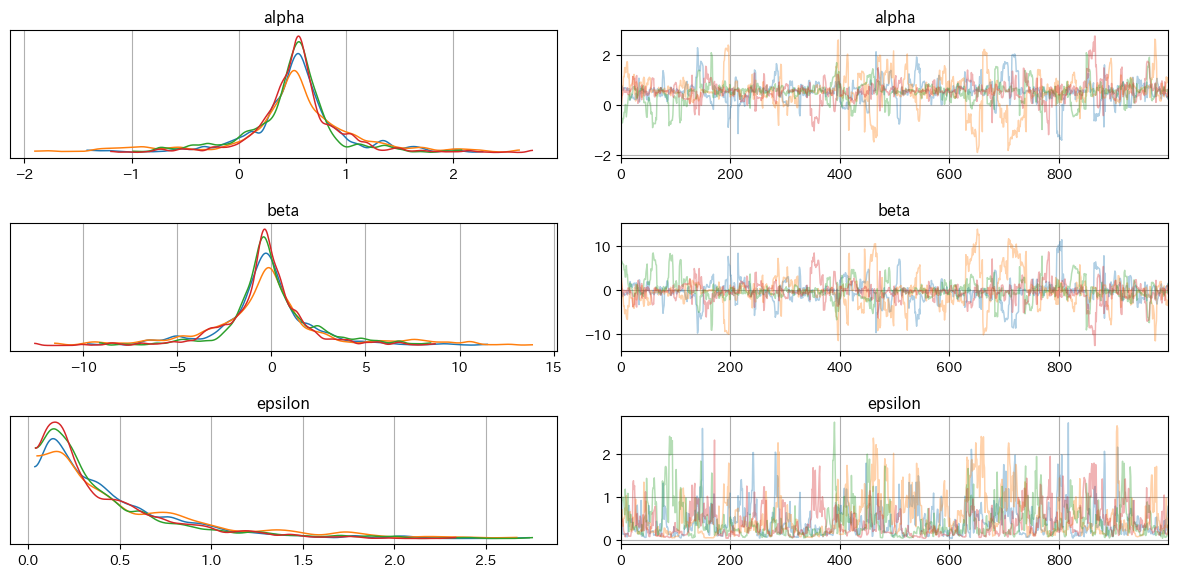

In [42]:
az.plot_trace(idata3, compact=False, var_names=['alpha', 'beta', 'epsilon'])
plt.tight_layout()

In [43]:
summary3 = az.summary(idata3, var_names=['alpha', 'beta', 'epsilon'])
display(summary3)

,mean,sd,hdi_3%,hdi_97%,mcse_mean,mcse_sd,ess_bulk,ess_tail,r_hat
alpha,0.521,0.491,-0.557,1.541,0.027,0.039,378.000,245.000,1.020
beta,-0.180,2.747,-6.046,5.821,0.152,0.216,371.000,243.000,1.020
epsilon,0.450,0.414,0.037,1.244,0.027,0.023,206.000,452.000,1.020


x_values.shape (2,)
alphas3.shape (4000, 1)
betas3.shape (4000, 1)


Text(0, 0.5, 'sepal_width')

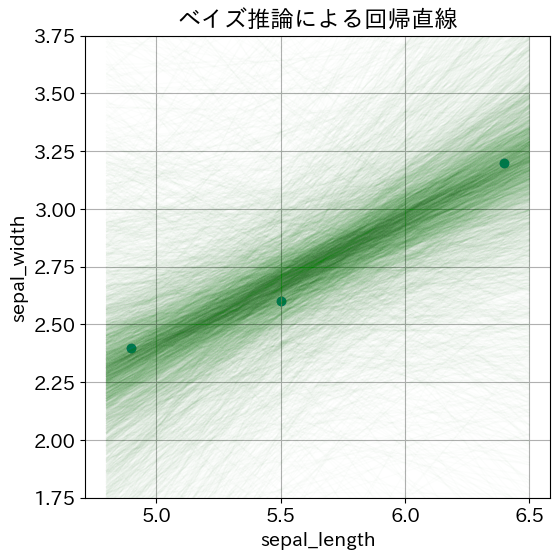

In [44]:
# 散布図と回帰直線の重ね書き
x_values = np.array([X_less.min()-0.1, X_less.max()+0.1])

alphas3 = idata3['posterior']['alpha'].values.reshape(-1, 1)
betas3 = idata3['posterior']['beta'].values.reshape(-1, 1)

print("x_values.shape", x_values.shape)
print("alphas3.shape", alphas3.shape)
print("betas3.shape", betas3.shape)

y_preds = x_values * alphas3 + betas3

for y_pred in y_preds:
    plt.plot(x_values, y_pred, lw=1, alpha=0.01, c='g')
plt.scatter(X_less, Y_less)
plt.ylim(1.75, 3.75)
plt.title("ベイズ推論による回帰直線")
plt.xlabel('sepal_length')
plt.ylabel('sepal_width')

# No.3 階層ベイズモデル

In [45]:
df = sns.load_dataset('iris')
display(df.head())

# speciesの分布確認
df['species'].value_counts()

,sepal_length,sepal_width,petal_length,petal_width,species
0,5.100,3.500,1.400,0.200,setosa
1,4.900,3.000,1.400,0.200,setosa
2,4.700,3.200,1.300,0.200,setosa
3,4.600,3.100,1.500,0.200,setosa
4,5.000,3.600,1.400,0.200,setosa


species
setosa        50
versicolor    50
virginica     50
Name: count, dtype: int64

In [46]:
# versicolorデータに加えて，setosaデータとvirginicaデータも利用する

# setosa
df_setosa = df.query('species == "setosa"')
# versicolor
df_versicolor = df.query('species == "versicolor"')
# virginica
df_virginica = df.query('species == "virginica"')

import random
random.seed(42)
indices = range(len(df_versicolor))
sample_indices = random.sample(indices, 3)

# それぞれ３行のデータレコードを抽出
df_setosa_sel = df_setosa.iloc[sample_indices]
df_versicolor_sel = df_versicolor.iloc[sample_indices]
df_virginica_sel = df_virginica.iloc[sample_indices]

df_sel = pd.concat([df_setosa_sel, df_versicolor_sel, df_virginica_sel]).reset_index(drop=True)
display(df_sel)

,sepal_length,sepal_width,petal_length,petal_width,species
0,5.000,3.500,1.300,0.300,setosa
1,5.000,3.400,1.500,0.200,setosa
2,4.900,3.000,1.400,0.200,setosa
3,5.500,2.600,4.400,1.200,versicolor
4,4.900,2.400,3.300,1.000,versicolor
5,6.400,3.200,4.500,1.500,versicolor
6,6.700,3.100,5.600,2.400,virginica
7,7.300,2.900,6.300,1.800,virginica
8,5.800,2.700,5.100,1.900,virginica


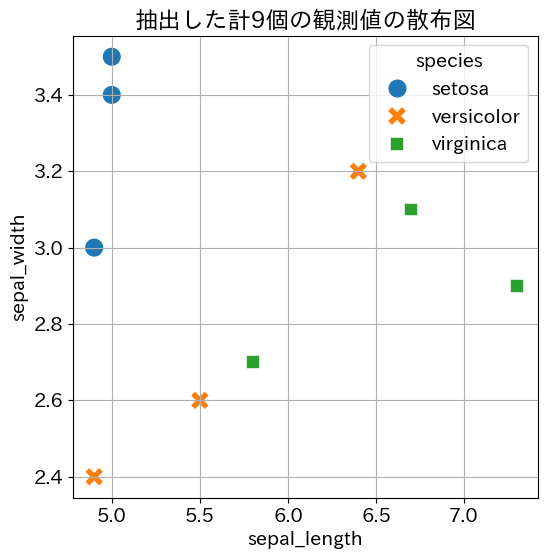

In [47]:
sns.scatterplot(x='sepal_length', y='sepal_width', hue='species', style='species', data=df_sel, s=200)
plt.title('抽出した計9個の観測値の散布図')
plt.show()

In [48]:
X = df_sel['sepal_length'].values
Y = df_sel['sepal_width'].values
species = df_sel['species']
cl = pd.Categorical(species).codes

print(X)
print(Y)
print(species.values)
print(cl)

[5.000 5.000 4.900 5.500 4.900 6.400 6.700 7.300 5.800]
[3.500 3.400 3.000 2.600 2.400 3.200 3.100 2.900 2.700]
['setosa' 'setosa' 'setosa' 'versicolor' 'versicolor' 'versicolor'
 'virginica' 'virginica' 'virginica']
[0 0 0 1 1 1 2 2 2]


In [49]:
model1 = pm.Model()

with model1:
    X_data = pm.Data('X_data', X)
    Y_data = pm.Data('Y_data', Y)

    # クラス変数定義(階層ベイズ固有)
    cl_data = pm.Data('cl_data', cl)

    # 確率変数alphaの定義(階層ベイズ固有)
    a_mu = pm.Normal('a_mu', mu=0.0, sigma=10.0)
    a_sigma = pm.HalfNormal('a_sigma', sigma=10.0)
    alpha = pm.Normal('alpha', mu=a_mu, sigma=a_sigma, shape=(3,))

    # 確率変数betaの定義(階層ベイズ固有)
    b_mu = pm.Normal('b_mu', mu=0.0, sigma=10.0)
    b_sigma = pm.HalfNormal('b_sigma', sigma=10.0)
    beta = pm.Normal('beta', mu=b_mu, sigma=b_sigma, shape=(3,))

    epsilon = pm.HalfNormal('epsilon', sigma=1.0)

    # muの値は, cl_dataによりindexを切り替えて計算(階層ベイズ固有)
    mu = pm.Deterministic('mu', X_data * alpha[cl_data] + beta[cl_data])

    obs = pm.Normal('obs', mu=mu, sigma=epsilon, observed=Y_data)
    

In [50]:
ALPHA = np.array([0.1, 0.2, 0.3])
print(ALPHA)

CL = np.array([0,0,0,1,1,1,2,2,2])
print(CL)

MU = ALPHA[CL]
print(MU)

[0.100 0.200 0.300]
[0 0 0 1 1 1 2 2 2]
[0.100 0.100 0.100 0.200 0.200 0.200 0.300 0.300 0.300]


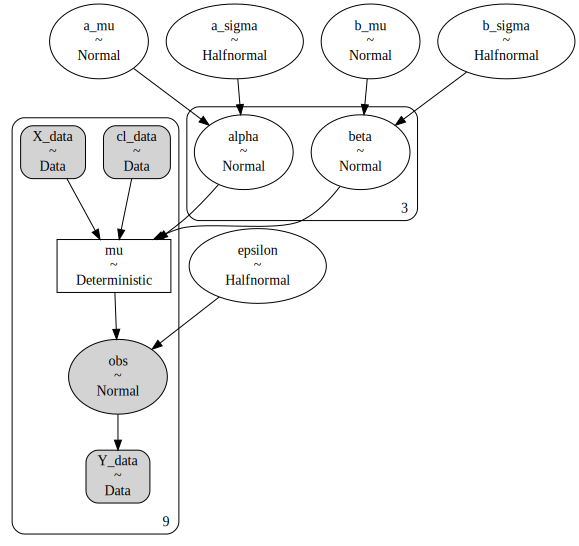

In [51]:
g = pm.model_to_graphviz(model1)
display(g)

In [52]:
with model1:
    idata1 = pm.sample(random_seed=42, target_accept=0.998)
    

Initializing NUTS using jitter+adapt_diag...
Multiprocess sampling (4 chains in 4 jobs)
NUTS: [a_mu, a_sigma, alpha, b_mu, b_sigma, beta, epsilon]


Output()

Sampling 4 chains for 1_000 tune and 1_000 draw iterations (4_000 + 4_000 draws total) took 52 seconds.
There were 37 divergences after tuning. Increase `target_accept` or reparameterize.
Chain 2 reached the maximum tree depth. Increase `max_treedepth`, increase `target_accept` or reparameterize.
The rhat statistic is larger than 1.01 for some parameters. This indicates problems during sampling. See https://arxiv.org/abs/1903.08008 for details
The effective sample size per chain is smaller than 100 for some parameters.  A higher number is needed for reliable rhat and ess computation. See https://arxiv.org/abs/1903.08008 for details


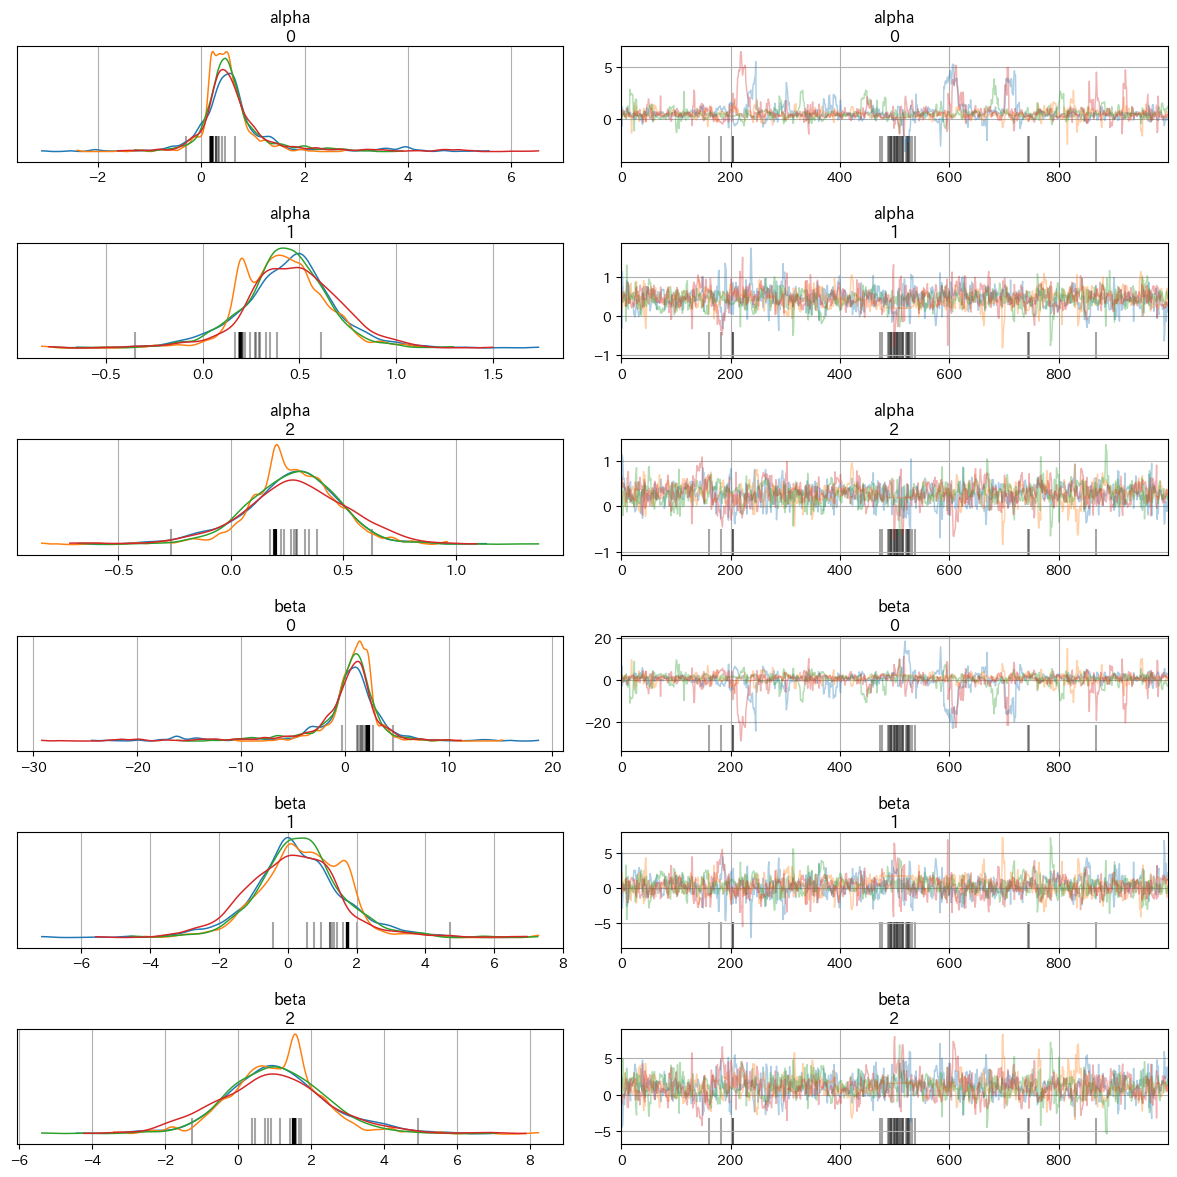

In [53]:
az.plot_trace(idata1, compact=False, var_names=['alpha', 'beta'])
plt.tight_layout()

In [54]:
summary1 = az.summary(idata1, var_names=['alpha', 'beta'])
display(summary1)

,mean,sd,hdi_3%,hdi_97%,mcse_mean,mcse_sd,ess_bulk,ess_tail,r_hat
alpha[0],0.619,0.770,-0.640,2.049,0.043,0.085,491.000,325.000,1.010
alpha[1],0.434,0.236,0.010,0.902,0.009,0.007,705.000,1068.000,1.010
alpha[2],0.279,0.222,-0.194,0.651,0.009,0.008,680.000,856.000,1.000
beta[0],0.214,3.818,-6.674,6.629,0.215,0.422,493.000,320.000,1.010
beta[1],0.312,1.327,-2.279,2.714,0.049,0.041,705.000,980.000,1.010
beta[2],1.057,1.462,-1.427,4.197,0.056,0.049,677.000,930.000,1.000


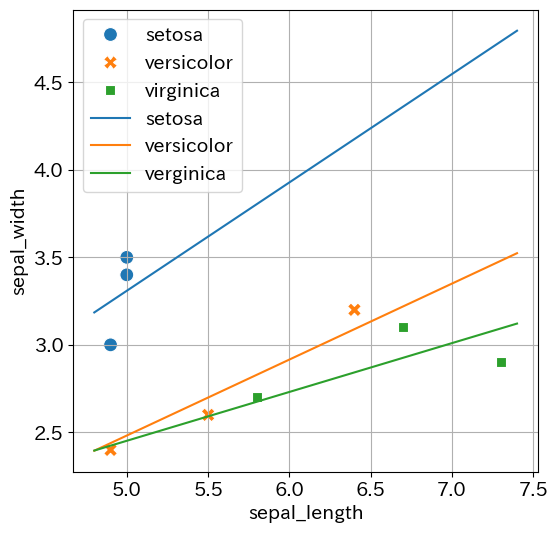

In [55]:
# alphaとbetaの平均値の導出
means = summary1['mean']
alpha0 = means['alpha[0]']
alpha1 = means['alpha[1]']
alpha2 = means['alpha[2]']
beta0 = means['beta[0]']
beta1 = means['beta[1]']
beta2 = means['beta[2]']

x_range = np.array([X.min()-0.1, X.max()+0.1])
y0_range = alpha0 * x_range + beta0
y1_range = alpha1 * x_range + beta1
y2_range = alpha2 * x_range + beta2


sns.scatterplot(
    x='sepal_length', y='sepal_width', hue='species', style='species',
    data=df_sel, s=100)
plt.plot(x_range, y0_range, label='setosa')
plt.plot(x_range, y1_range, label='versicolor')
plt.plot(x_range, y2_range, label='verginica')
plt.legend()

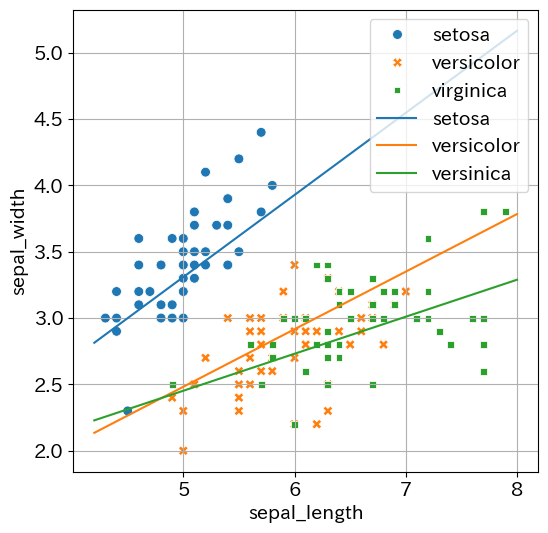

In [56]:
x_range = np.array([
    df['sepal_length'].min() - 0.1,
    df['sepal_length'].max() + 0.1
])

y0_range = alpha0 * x_range + beta0
y1_range = alpha1 * x_range + beta1
y2_range = alpha2 * x_range + beta2

sns.scatterplot(x='sepal_length', y='sepal_width', hue='species', style='species', s=50, data=df)
plt.plot(x_range, y0_range, label='setosa')
plt.plot(x_range, y1_range, label='versicolor')
plt.plot(x_range, y2_range, label='versinica')
plt.legend()

# No.5 潜在変数モデル

In [57]:
df = sns.load_dataset('iris')
display(df.head)
df['species'].value_counts()

<bound method NDFrame.head of      sepal_length  sepal_width  petal_length  petal_width    species
0           5.100        3.500         1.400        0.200     setosa
1           4.900        3.000         1.400        0.200     setosa
2           4.700        3.200         1.300        0.200     setosa
3           4.600        3.100         1.500        0.200     setosa
4           5.000        3.600         1.400        0.200     setosa
..            ...          ...           ...          ...        ...
145         6.700        3.000         5.200        2.300  virginica
146         6.300        2.500         5.000        1.900  virginica
147         6.500        3.000         5.200        2.000  virginica
148         6.200        3.400         5.400        2.300  virginica
149         5.900        3.000         5.100        1.800  virginica

[150 rows x 5 columns]>

species
setosa        50
versicolor    50
virginica     50
Name: count, dtype: int64

In [63]:
df2 = df.query('species != "setosa"')
df2 = df2.reset_index(drop=True) # インデックスを0から振り直す
X = df2['petal_width'].values

In [66]:
X

array([1.400, 1.500, 1.500, 1.300, 1.500, 1.300, 1.600, 1.000, 1.300,
       1.400, 1.000, 1.500, 1.000, 1.400, 1.300, 1.400, 1.500, 1.000,
       1.500, 1.100, 1.800, 1.300, 1.500, 1.200, 1.300, 1.400, 1.400,
       1.700, 1.500, 1.000, 1.100, 1.000, 1.200, 1.600, 1.500, 1.600,
       1.500, 1.300, 1.300, 1.300, 1.200, 1.400, 1.200, 1.000, 1.300,
       1.200, 1.300, 1.300, 1.100, 1.300, 2.500, 1.900, 2.100, 1.800,
       2.200, 2.100, 1.700, 1.800, 1.800, 2.500, 2.000, 1.900, 2.100,
       2.000, 2.400, 2.300, 1.800, 2.200, 2.300, 1.500, 2.300, 2.000,
       2.000, 1.800, 2.100, 1.800, 1.800, 1.800, 2.100, 1.600, 1.900,
       2.000, 2.200, 1.500, 1.400, 2.300, 2.400, 1.800, 1.800, 2.100,
       2.400, 2.300, 1.900, 2.300, 2.500, 2.300, 1.900, 2.000, 2.300,
       1.800])

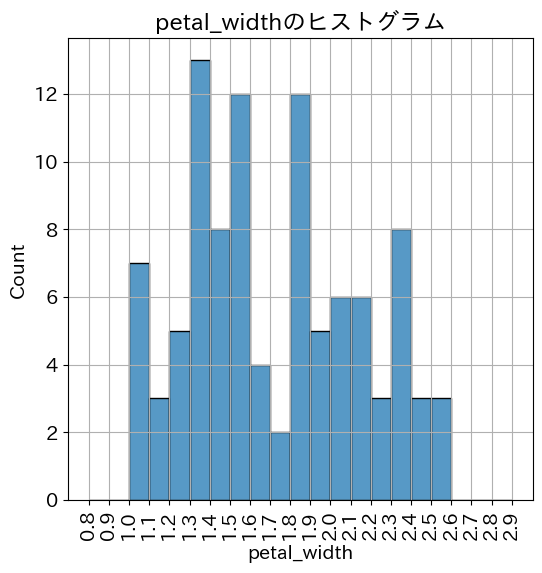

In [67]:
# 分析対象を色分けなしにヒストグラム表示
bins = np.arange(0.8, 3.0, 0.1)
fig, ax = plt.subplots()
sns.histplot(bins=bins, x=X)
ax.set_xlabel('petal_width')
ax.xaxis.set_tick_params(rotation=90)
ax.set_title('petal_widthのヒストグラム')
ax.set_xticks(bins)

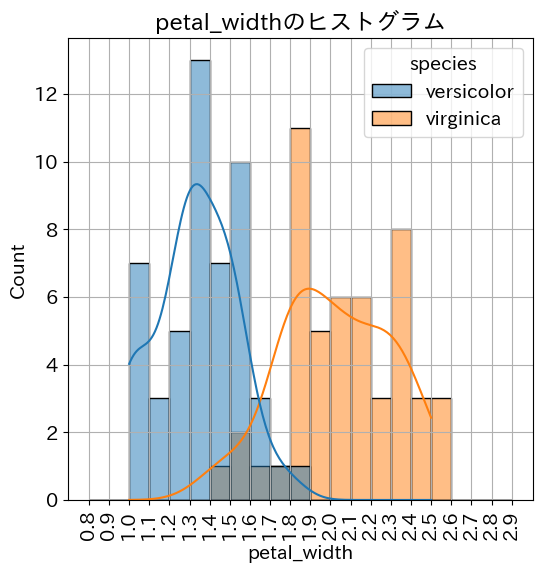

In [68]:
# 花の種類で色分けしたヒストグラム表示
bins = np.arange(0.8, 3.0, 0.1)
fig, ax = plt.subplots()
sns.histplot(data=df2, bins=bins, x="petal_width", hue="species", kde=True)
ax.xaxis.set_tick_params(rotation=90)
ax.set_title('petal_widthのヒストグラム')
ax.set_xticks(bins)

In [76]:
# 一様分布とベルヌーイ分布 for 潜在変数S

# 潜在変数モデルに対する確率モデルの定義

n_components = 2

N = X.shape # 観測データ数

model1 = pm.Model()

with model1:
    X_data = pm.Data('X_data', X)

    p = pm.Uniform('p', lower=0.0, upper=1.0) # p: 潜在変数が1をとる確率
    s = pm.Bernoulli('s', p=p, shape=N) # s: 潜在変数

    # mus: 2つの花の種類ごとの平均値
    mus = pm.Normal('mus', mu=0.0, sigma=10.0, shape=n_components)

    # taus: 2つの花の種類ごとのばらつき
    taus = pm.HalfNormal('taus', sigma=10.0, shape=n_components)

    # グラフ描画など分析でシグマが必要
    sigmas = pm.Deterministic('sigmas', 1/pm.math.sqrt(taus))

    # 各観測値ごとに潜在変数からmuとtauを求める
    mu = pm.Deterministic('mu', mus[s])
    tau = pm.Deterministic('tau', taus[s])

    # 正規分布に従う確率変数X_obsの定義
    X_obs = pm.Normal('X_obs', mu=mu, tau=tau, observed=X_data)



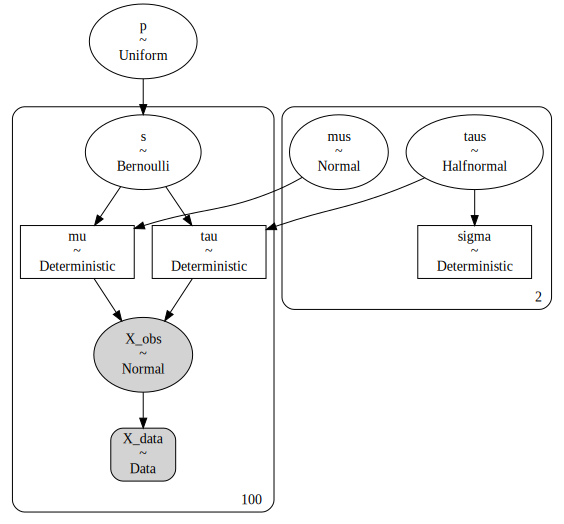

In [73]:
g = pm.model_to_graphviz(model1)
display(g)

In [83]:
# サンプリングの実装
with model1:
    idata1 = pm.sample(chains=1, draws=2000, target_accept=0.99, random_seed=42)

Sequential sampling (1 chains in 1 job)
CompoundStep
>NUTS: [p, mus, taus]
>BinaryGibbsMetropolis: [s]


Output()

Sampling 1 chain for 1_000 tune and 2_000 draw iterations (1_000 + 2_000 draws total) took 10 seconds.
Only one chain was sampled, this makes it impossible to run some convergence checks


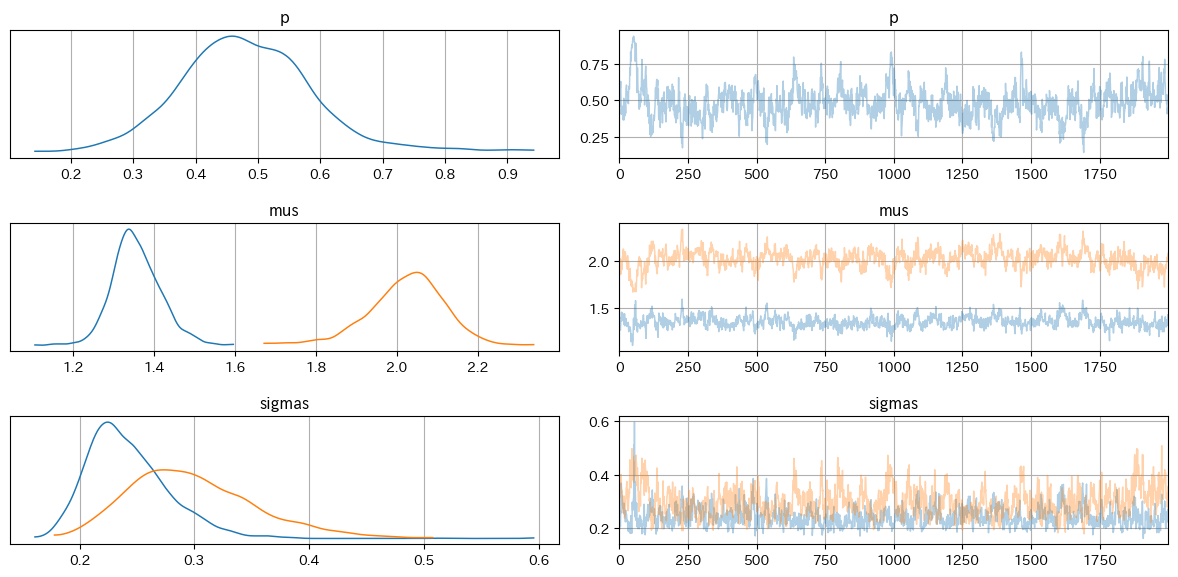

In [84]:
az.plot_trace(idata1, var_names=['p', 'mus', 'sigmas'], compact=True)
plt.tight_layout()

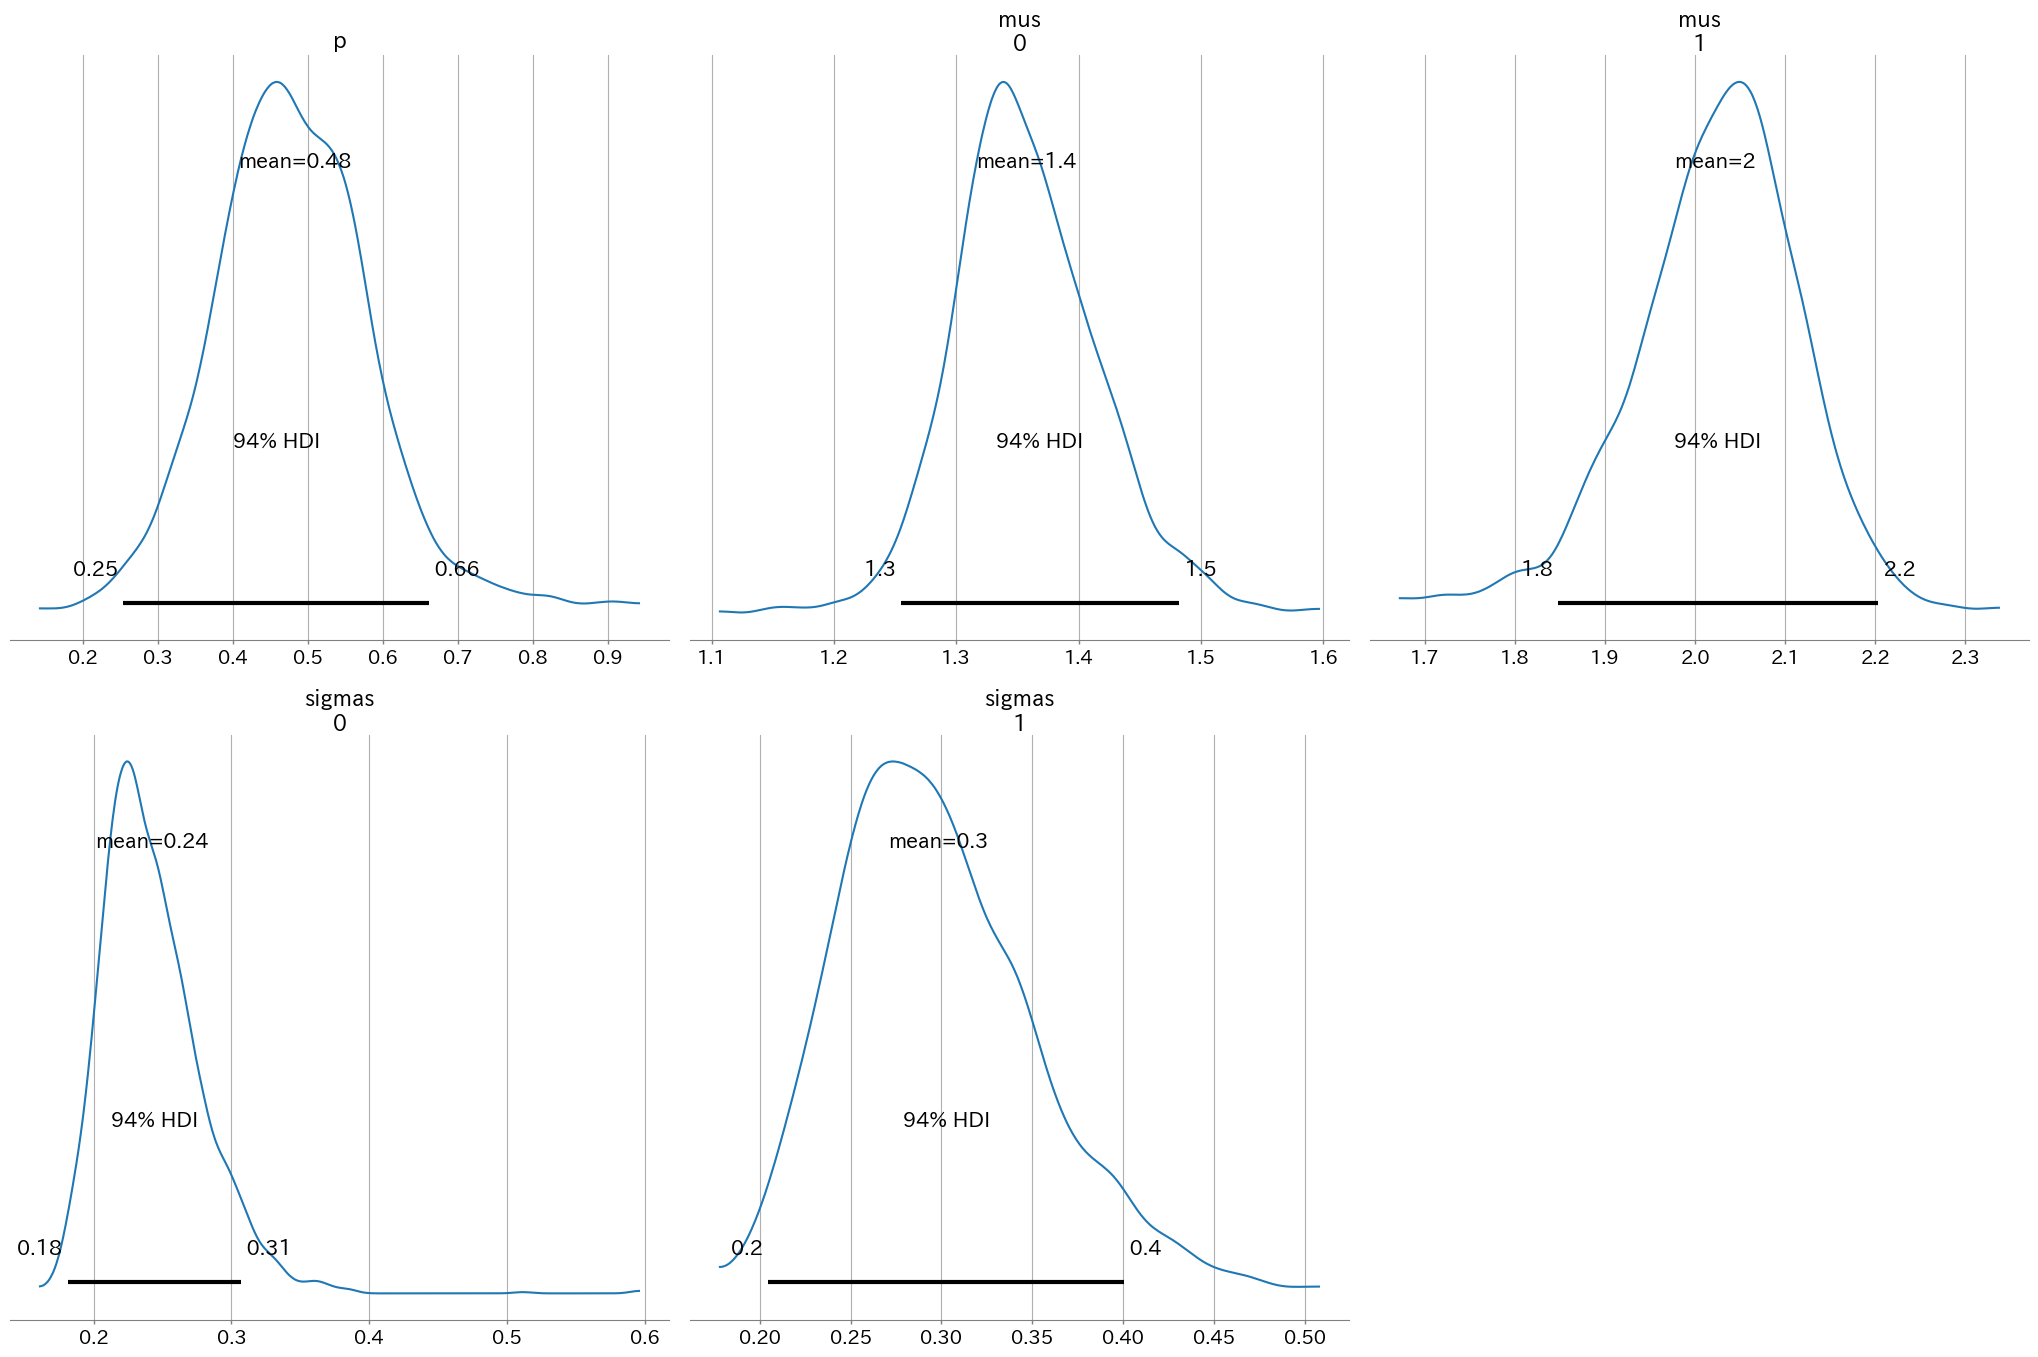

In [85]:
# 各確率変数の事後分布を表示
plt.rcParams['figure.figsize'] = (6,6)
az.plot_posterior(idata1, var_names=['p', 'mus', 'sigmas'])
plt.tight_layout()

In [86]:
summary1 = az.summary(idata1, var_names=['p','mus','sigmas'])
display(summary1)

arviz - WARNING - Shape validation failed: input_shape: (1, 2000), minimum_shape: (chains=2, draws=4)


,mean,sd,hdi_3%,hdi_97%,mcse_mean,mcse_sd,ess_bulk,ess_tail,r_hat
p,0.483,0.110,0.254,0.662,0.011,0.008,100.000,178.000,NaN
mus[0],1.357,0.060,1.255,1.482,0.005,0.003,176.000,330.000,NaN
mus[1],2.023,0.095,1.848,2.203,0.010,0.006,101.000,131.000,NaN
sigmas[0],0.242,0.036,0.181,0.307,0.002,0.002,274.000,385.000,NaN
sigmas[1],0.298,0.055,0.205,0.400,0.005,0.003,109.000,177.000,NaN


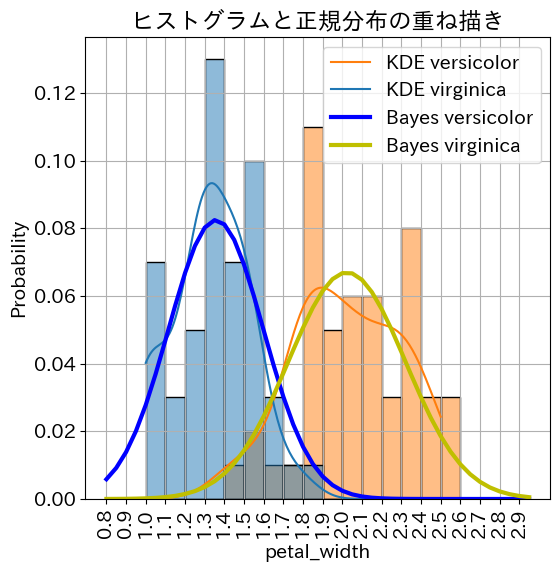

In [89]:
# ヒストグラムと正規分布関数の重ね書き

def norm(x, mu, sigma):
    return np.exp(-((x-mu)/sigma)**2/2) / (np.sqrt(2*np.pi)*sigma)

# 各平均
mean = summary1['mean']

# muの平均
mean_mu0 = mean['mus[0]']
mean_mu1 = mean['mus[1]']

# sigmaの平均
mean_sigma0 = mean['sigmas[0]']
mean_sigma1 = mean['sigmas[1]']

# 正規分布関数値の計算
x = np.arange(0.8, 3.0, 0.05)
delta = 0.1
y0 = norm(x, mean_mu0, mean_sigma0) * delta / n_components
y1 = norm(x, mean_mu1, mean_sigma1) * delta / n_components

# グラフ描画
bins = np.arange(0.8, 3.0, delta)
plt.rcParams['figure.figsize'] = (6,6)
fig, ax = plt.subplots()
sns.histplot(data=df2, bins=bins,
             x='petal_width',
             hue='species',
             kde=True,
             ax=ax,
             stat='probability')
ax.get_lines()[0].set_label('KDE versicolor')
ax.get_lines()[1].set_label('KDE virginica')
ax.plot(x, y0, c='b', lw=3, label='Bayes versicolor')
ax.plot(x, y1, c='y', lw=3, label='Bayes virginica')
ax.set_xticks(bins)
ax.xaxis.set_tick_params(rotation=90)
ax.set_title('ヒストグラムと正規分布の重ね描き')
plt.legend()


定義した潜在変数の状態と挙動をチェック

In [90]:
value_list = [1.0, 1.5, 1.7, 2.0, 2.5]

df_heads = pd.DataFrame(None)

# petal_widthの値が1.0から2.5までそれぞれの値である先頭の行を抽出
for value in value_list:
    # df2からpetal_widthの値がvalueである行のみ抽出
    w = df2.query('`petal_width`==@value', engine='python')

    # 先頭の1行を抽出し，df_headsに連結
    df_heads = pd.concat([df_heads, w.head(1)], axis=0)

display(df_heads)

,sepal_length,sepal_width,petal_length,petal_width,species
7,4.900,2.400,3.300,1.000,versicolor
1,6.400,3.200,4.500,1.500,versicolor
27,6.700,3.000,5.000,1.700,versicolor
60,6.500,3.200,5.100,2.000,virginica
50,6.300,3.300,6.000,2.500,virginica


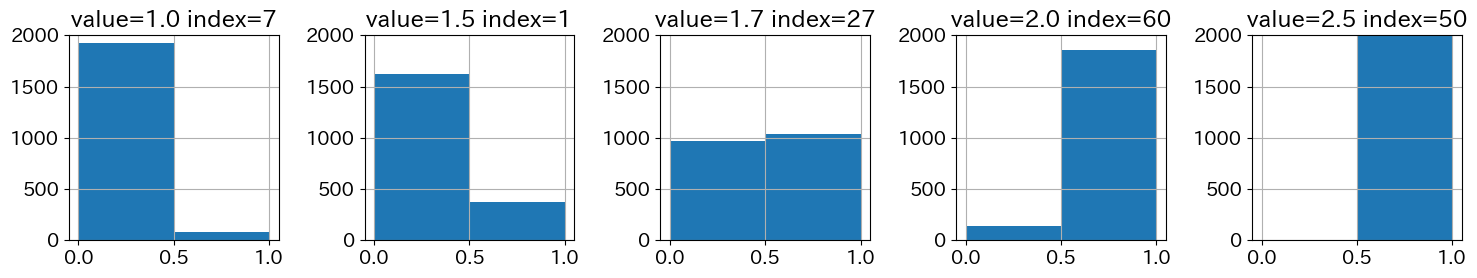

In [91]:
# df_headsのインデックスを抽出
indexes, n_indexes = df_heads.index, len(df_heads)

# 潜在変数sのサンプル値から, index=7,1,27,60,50の値を抽出
sval = idata1.posterior['s'][:,:,indexes].values.reshape(-1, n_indexes).T # [chains, draws, nums] of 's'

# それぞれのケースでヒストグラムの描画
plt.rcParams['figure.figsize'] = (15, 3)
vlist = df_heads['petal_width']
fig, axes = plt.subplots(1, n_indexes)
for ax, item, value, index in zip(axes, sval, vlist, indexes):
    f = pd.DataFrame(item)
    f.hist(ax=ax, bins=2)
    ax.set_ylim(0,2000)
    ax.set_title(f'value={value} index={index}')
plt.tight_layout()